In [2]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [16]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS  = json.load(f)
SPLITSDIR    = CONFIGS['filepaths']['splits']
WEIGHTSDIR   = CONFIGS['filepaths']['weights']
MODELSDIR    = CONFIGS['filepaths']['models']
FIELDVARS    = CONFIGS['experiments']['sr']['runs']['sr_atm']['fieldvars']
SEEDS        = CONFIGS['experiments']['nn']['seeds']
SPLIT        = 'test'
SAMPLETHRESH = 50
NCUBES       = [3,4,5,6,7]
PCS          = {
    'r$\\mathrm{PC}_1$':{'label':r'$\frac{\partial\mathrm{P}}{\partial\widehat{\mathrm{RH}}} \geq 0$',
           'testvar':'rh','expectedsign':1,'othervars':['thetae','thetaestar']},
    'r$\\mathrm{PC}_2$':{'label':r'$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e}} \geq 0$',
           'testvar':'thetae','expectedsign':1,'othervars':['rh','thetaestar']},
    'r$\\mathrm{PC}_3$':{'label':r'$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e^*}} \leq 0$',
           'testvar':'thetaestar','expectedsign':-1,'othervars':['rh','thetae']}}

In [17]:
def load_flat(ds,name,grid):
    values = xr.broadcast(ds[name],grid)[0]
    return values.transpose('time','lat','lon').values.ravel()

def hypercube_test(testedvar,expectedsign,othervars,ncubes,regionmask,samplethresh=SAMPLETHRESH):
    tested = integrals[:,FIELDVARS.index(testedvar)]
    condit = [integrals[:,FIELDVARS.index(name)] for name in othervars]
    binedges = [np.linspace(*np.percentile(values[regionmask],[1,99]),ncubes+1) for values in condit]
    binidxs  = [np.clip(np.digitize(values,bounds)-1,0,ncubes-1) for values,bounds in zip(condit,binedges)]
    cubeidxs = binidxs[0]*ncubes+binidxs[1]
    results = []
    for cubeidx in range(ncubes**2):
        selected = regionmask&(cubeidxs==cubeidx)
        if selected.sum()<samplethresh:
            continue
        testedvalues,tpvalues = tested[selected],tp[selected]
        centered = testedvalues-testedvalues.mean()
        slope = np.dot(centered,tpvalues)/(np.dot(centered,centered)+1e-12)
        results.append((slope,slope*expectedsign>=0,testedvalues.mean(),
                        tpvalues.mean(),np.mean(tpvalues==0)))
    return pd.DataFrame(results,columns=['slope','satisfied','meantest','meantp','zerofrac'])

def test_physical_constraint(pc,n,regionmask):
    return hypercube_test(pc['testvar'],pc['expectedsign'],pc['othervars'],n,regionmask)

In [18]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    fieldgrid = ds[FIELDVARS].to_array('feature').transpose('time','lat','lon','feature','sig')
    fields    = fieldgrid.values.reshape(-1,len(FIELDVARS),ds.sig.size)
    dsig      = ds.dsig.values
    lf        = load_flat(ds,'lf',ds[FIELDVARS[0]].isel(sig=0))
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    tp = ds.tp.transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds.k.values)
meankernel = np.mean(kernels,axis=0)
integrals  = (fields*meankernel[None,:,:]*dsig[None,None,:]).sum(axis=2)

finite = np.isfinite(integrals).all(axis=1)&np.isfinite(tp)
integrals,lf,tp = integrals[finite],lf[finite],tp[finite]

rh,thetae,thetaestar       = (integrals[:,FIELDVARS.index(name)] for name in ['rh','thetae','thetaestar'])
landmask,oceanmask,allmask = lf>=0.5,lf<0.5,np.ones(len(tp),dtype=bool)

In [19]:
era5rows = []
for pcname,pc in PCS.items():
    for region,mask in [('Land',landmask),('Ocean',oceanmask),('All',allmask)]:
        scores = {}
        for n in NCUBES:
            cubes = test_physical_constraint(pc,n,mask)
            scores[rf'$n = {n}$'] = 100*cubes.satisfied.mean()
        era5rows.append({'Constraint':pcname,'Region':region,**scores,'Average':np.mean(list(scores.values()))})
era5df = pd.DataFrame(era5rows)

display(era5df.style.hide(axis='index').format({**{rf'$n = {n}$':'{:.1f}%' for n in NCUBES},'Average':'{:.1f}%'}))

Constraint,Region,$n = 3$,$n = 4$,$n = 5$,$n = 6$,$n = 7$,Average
r$\mathrm{PC}_1$,Land,100.0%,100.0%,95.8%,100.0%,100.0%,99.2%
r$\mathrm{PC}_1$,Ocean,77.8%,62.5%,56.0%,58.3%,58.3%,62.6%
r$\mathrm{PC}_1$,All,100.0%,87.5%,83.3%,80.0%,85.1%,87.2%
r$\mathrm{PC}_2$,Land,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
r$\mathrm{PC}_2$,Ocean,88.9%,100.0%,100.0%,96.9%,100.0%,97.2%
r$\mathrm{PC}_2$,All,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
r$\mathrm{PC}_3$,Land,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
r$\mathrm{PC}_3$,Ocean,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
r$\mathrm{PC}_3$,All,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%


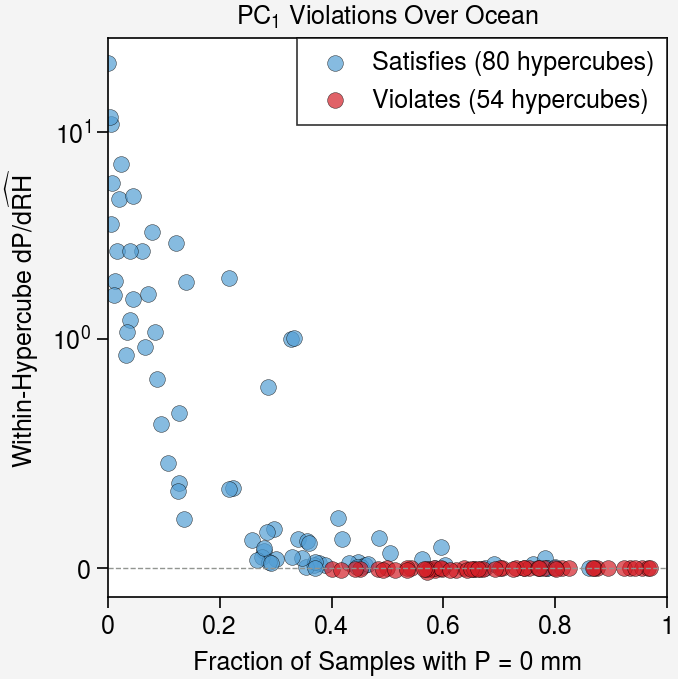

In [20]:
allcubes = pd.concat([test_physical_constraint(PCS[next(iter(PCS))],n,oceanmask) for n in NCUBES],ignore_index=True)

fig,ax = pplt.subplots(figwidth=3.5)
ax.format(grid=False,xlabel='Fraction of Samples with P = 0 mm',xlim=(0,1),xticks=0.2,
          ylabel=r'Within-Hypercube $dP/d\widehat{RH}$',yscale='symlog',yformatter='log',
          title=r'$PC_1$ Violations Over Ocean')
for satisfied,color,label in [(True,'#539ED4','Satisfies'),(False,'#D42028','Violates')]:
    cubes = allcubes[allcubes.satisfied==satisfied]
    ax.scatter(cubes.zerofrac,cubes.slope,color=color,s=32,alpha=0.7,
               edgecolor='k',linewidth=0.2,label=f'{label} ({len(cubes)} hypercubes)')
ax.axhline(0,color='gray',linewidth=0.5,linestyle='--')
ax.legend(loc='ur',ncols=1)
pplt.show()
fig.save('../figs/fig_S2.jpg')

In [22]:
regdf = pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv'))
constants = {row['name']:json.loads(row['constants']) for _,row in regdf.iterrows()}

def sr_atm_gradient(atm):
    argument = thetae-atm['b']*thetaestar-atm['c']
    rhbranch = rh>=argument
    return {'rh':np.where(rhbranch,3*atm['a']*rh**2,0.0),
            'thetae':np.where(rhbranch,0.0,3*atm['a']*argument**2),
            'thetaestar':np.where(rhbranch,0.0,-3*atm['a']*atm['b']*argument**2)}

def sr_sfc_gradient(atm):
    return sr_atm_gradient(atm)
    
def sr_all_gradient(atm,correction):
    gradient = sr_atm_gradient(atm)
    gradient['thetae'] += (correction['b']-lf)**3
    return gradient
    
def sr_all_pc_gradient(atm,correction):
    gradient = sr_atm_gradient(atm)
    gradient['thetae'] += (correction['b']-lf)**3-(correction['b']-1)**3
    return gradient

gradients = {
    'SR-ATM':sr_atm_gradient(constants['sr_atm_eq']),
    'SR-SFC':sr_sfc_gradient(constants['sr_atm_eq']),
    'SR-ALL':sr_all_gradient(constants['sr_atm_eq'],constants['sr_all_eq']),
    'SR-ALL-PC':sr_all_pc_gradient(constants['sr_atm_eq'],constants['sr_all_pc_eq'])}

era5    = era5df.set_index(['Constraint','Region'])['Average']
pcnames = list(PCS)
regions = ['Land','All','All']
masks   = [landmask,allmask,allmask]
rows    = [{'Model':'ERA5',**{PCS[pcname]['label']:era5[pcname,region] for pcname,region in zip(pcnames,regions)}}]

for model,gradient in gradients.items():
    row = {'Model':model}
    for pcname,mask in zip(pcnames,masks):
        satisfied = gradient[PCS[pcname]['testvar']]*PCS[pcname]['expectedsign']>=0
        row[PCS[pcname]['label']] = 100*satisfied[mask].mean()
    rows.append(row)
table = pd.DataFrame(rows)

display(table.style.hide(axis='index').format({pc['label']:'{:.1f}%' for pc in PCS.values()}))

Model,$\frac{\partial\mathrm{P}}{\partial\widehat{\mathrm{RH}}} \geq 0$,$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e}} \geq 0$,$\frac{\partial\mathrm{P}}{\partial\widehat{\theta_e^*}} \leq 0$
ERA5,99.2%,100.0%,100.0%
SR-ATM,100.0%,100.0%,100.0%
SR-SFC,100.0%,100.0%,100.0%
SR-ALL,100.0%,88.7%,100.0%
SR-ALL-PC,100.0%,100.0%,100.0%
